In [242]:
!pip install qiskit[visualization]
!pip install qiskit-aer
!pip install qiskit-ibm-runtime
!pip install pymatching

In [243]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import pymatching
import numpy as np

Here we are considereing rotated surface code with distance d=3. Let's assume data qubits and ancilla qubits placed as below diagram.

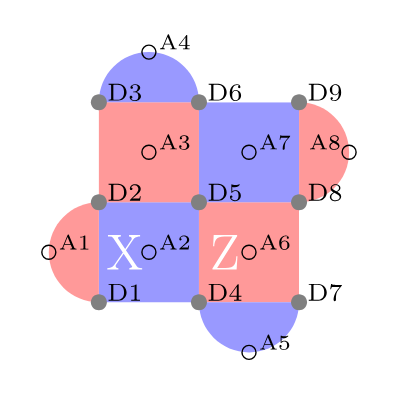

Fig: The qubit layout of a distance-3 rotated surface code, where data qubits are on the vertices (solid circles) and X- and Z-ancilla qubits are on the purple and pink plaquettes (open circles), respectively.

Data: D1–D9, Ancilla: A1–A8

Grid layout (row, col), spacing:

D3=(0,0)  
D6=(0,1)  
D9=(0,2)  
D2=(1,0)  
D5=(1,1)  
D8=(1,2)  
D1=(2,0)  
D4=(2,1)  
D7=(2,2)
  

---


  
  X stabilizers (purple faces) — 2 interior + 2 boundary:

A2: [D2, D5, D1, D4]  (weight-4)

A7: [D6, D9, D5, D8]  (weight-4)

A4: [D3, D6] (top left boundary, weight-2)

A5: [D4, D7] (bottom right boundary, weight-2)


---



Z stabilizers (pink faces) — 2 interior + 2 boundary:

A3: [D3, D6, D2, D5]  (weight-4)

A6: [D5, D8, D4, D7]  (weight-4)

A1: [D1, D2] (bottom left boundary, weight -2)

A8: [D9, D8] (top-right boundary, weight-2)

In [252]:
#Data qubits: → D1..D9
D = QuantumRegister(9, 'D')

# Ancilla qubits:→ A1..A8
A = QuantumRegister(8, 'A')

# Syndrome classical bits: s[0]..s[7] correspond to A1..A8
S1 = ClassicalRegister(8, 's1')
S2 = ClassicalRegister(8, 's2')
# F = ClassicalRegister(9, 'Corrected_result') # Final verification round

qc = QuantumCircuit(D, A, S1, S2)

\|0⟩$_L$

# Step1:
Encoding logical-|0⟩ or |0⟩$_L$ state.




In [245]:
# All data qubits default to |0⟩. No prep neeeded for logical |0⟩ here.
qc.barrier(label="|0⟩_L encoded")
# qc.draw(output = 'mpl')


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "D"), index=0>, <Qubit register=(9, "D"), index=1>, <Qubit register=(9, "D"), index=2>, <Qubit register=(9, "D"), index=3>, <Qubit register=(9, "D"), index=4>, <Qubit register=(9, "D"), index=5>, <Qubit register=(9, "D"), index=6>, <Qubit register=(9, "D"), index=7>, <Qubit register=(9, "D"), index=8>, <Qubit register=(8, "A"), index=0>, <Qubit register=(8, "A"), index=1>, <Qubit register=(8, "A"), index=2>, <Qubit register=(8, "A"), index=3>, <Qubit register=(8, "A"), index=4>, <Qubit register=(8, "A"), index=5>, <Qubit register=(8, "A"), index=6>, <Qubit register=(8, "A"), index=7>), clbits=())

# Step 2:

Z-TYPE stabilizers (detect X/bit-flip errors)

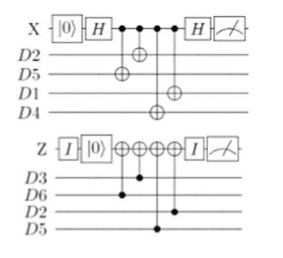

Fig: Error syndrome measurement circuits for X- and Z-stabilizers (X$_{D5, D2, D4, D1}$ and Z$_{D6, D3, D5, D2}$)

In [253]:
def measurement_cycle(cl_reg):

  # Z Stabilizer
  # Protocol: ancilla starts |0>
  #   CNOT(data_qubit (control) → ancilla(target)) for each neighbor
  #   Measure ancilla → gives ZZ parity of neighbors

  # Z Stabilizer    Ancilla    Data neighbors
  #   Z(A3)        A[2]      D3,D6,D2,D5  = D[2],D[5],D[1],D[4]
  #   Z(A6)        A[5]      D5,D8,D4,D7  = D[4],D[7],D[3],D[6]
  #   Z(A1)        A[0]      D2,D1        = D[1],D[0]
  #   Z(A8)        A[7]      D9,D8        = D[8],D[7]


  # Z stabilizer A3: neighbors D3, D6, D2, D5
  qc.cx(D[2], A[2])   # D3 → A3
  qc.cx(D[5], A[2])   # D6 → A3
  qc.cx(D[1], A[2])   # D2 → A3
  qc.cx(D[4], A[2])   # D5 → A3
  qc.measure(A[2], cl_reg[2])
  qc.reset(A[2])

  # Z stabilizer A6: neighbors D5, D8, D4, D7
  qc.cx(D[4], A[5])   # D5 → A7
  qc.cx(D[7], A[5])   # D8 → A7
  qc.cx(D[3], A[5])   # D4 → A7
  qc.cx(D[6], A[5])   # D7 → A7

  qc.measure(A[5], cl_reg[5])
  qc.reset(A[5])

  # Z stabilizer A1: neighbors D2, D1
  qc.cx(D[1], A[0])   # D2 → A1
  qc.cx(D[0], A[0])   # D1 → A1
  qc.measure(A[0], cl_reg[0])
  qc.reset(A[0])

  # Z stabilizer A8: neighbors D9, D8
  qc.cx(D[8], A[7])   # D9 → A8
  qc.cx(D[7], A[7])   # D8 → A8
  qc.measure(A[7], cl_reg[7])
  qc.reset(A[7])

  qc.barrier()


  # X stabilizers:
  # Protocol: ancilla starts |+> (apply H)
  #   CNOT(ancilla (control) → data_qubit(target)) for each neighbor
  #   H on ancilla, then measure → gives XX parity of neighbors
  #
  # Boundary X stabilizers:
  #   X(A2)  A[1]   D1, D2, D4, D5       = D[0], D[1], D[3], D[4]
  #   X(A7)  A[6]   D5, D6, D8, D9       = D[4], D[5], D[7], D[8]
  #   X(A4)  A[3]   D3, D6               = D[2], D[5]
  #   X(A5)  A[4]   D4, D7               = D[3], D[6]

  # X stabilizer A2: neighbors D1, D2, D4, D5
  qc.h(A[1])
  qc.cx(A[1], D[0])   # A2 → D1
  qc.cx(A[1], D[1])   # A2 → D2
  qc.cx(A[1], D[3])   # A2 → D4
  qc.cx(A[1], D[4])   # A2 → D5
  qc.h(A[1])
  qc.measure(A[1], cl_reg[1])
  qc.reset(A[1])

  # X stabilizer A7: neighbors D5, D6, D8, D9
  qc.h(A[6])
  qc.cx(A[6], D[4])   # A7 → D5
  qc.cx(A[6], D[5])   # A7 → D6
  qc.cx(A[6], D[7])   # A7 → D8
  qc.cx(A[6], D[8])   # A7 → D9
  qc.h(A[6])
  qc.measure(A[6], cl_reg[6])
  qc.reset(A[6])

  # X stabilizer A4: neighbors D3, D6
  qc.h(A[3])
  qc.cx(A[3], D[2])   # A4 → D3
  qc.cx(A[3], D[5])   # A4 → D6
  qc.h(A[3])
  qc.measure(A[3], cl_reg[3])
  qc.reset(A[3])

  # X stabilizer A5: neighbors D4, D7
  qc.h(A[4])
  qc.cx(A[4], D[3])   # A5 → D4
  qc.cx(A[4], D[6])   # A5 → D7
  qc.h(A[4])
  qc.measure(A[4], cl_reg[4])
  qc.reset(A[4])

In [254]:
measurement_cycle(S1)
qc.barrier(label="Measurement cycle 1 done")

"""INJECT ERROR BETWEEN TWO CYCLES"""
# --- Test: X error on D5 (center qubit) ---
# Should trigger Z stabilizers: A3, A6
qc.x(D[4])

# --- Test: Z error on D5 ---
# Should trigger X stabilizers touching D5: A2, A7
qc.z(D[4])

qc.barrier(label="Test error")

measurement_cycle(S2)
qc.barrier(label="Measurement cycle 2 done")

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "D"), index=0>, <Qubit register=(9, "D"), index=1>, <Qubit register=(9, "D"), index=2>, <Qubit register=(9, "D"), index=3>, <Qubit register=(9, "D"), index=4>, <Qubit register=(9, "D"), index=5>, <Qubit register=(9, "D"), index=6>, <Qubit register=(9, "D"), index=7>, <Qubit register=(9, "D"), index=8>, <Qubit register=(8, "A"), index=0>, <Qubit register=(8, "A"), index=1>, <Qubit register=(8, "A"), index=2>, <Qubit register=(8, "A"), index=3>, <Qubit register=(8, "A"), index=4>, <Qubit register=(8, "A"), index=5>, <Qubit register=(8, "A"), index=6>, <Qubit register=(8, "A"), index=7>), clbits=())

STEP 3:

Simulation

In [255]:
sim = AerSimulator()
job = sim.run(transpile(qc, sim), shots=1)
counts = job.result().get_counts()
print(counts) #counts :round 2, round1

{'01110100 00010010': 1}


Lookup Table:


In [256]:
for bits, _ in counts.items():
    print(f"  {bits}")
    b2, b1 = bits.split()

    #Calculate the SYNDROME (XOR the measurement cycles 1 &2)
    """
    int(b1, 2) and int(b2, 2): These convert two binary strings
    (b1 and b2) into their integer equivalents.
    int(b1, 2): 2 means my string b1 is binary.
    ^:Bitwise XOR operation
    """
    syndrome = int(b2, 2) ^ int(b1, 2)
    syn_str = format(syndrome, '08b')[::-1] # Binary string A1..A8

    print(f"\nMeasuremnt cycle 1: {b1[::-1]}")
    print(f"Measuremnt cycle 2: {b2[::-1]}")
    print(f"Syndrome: {syn_str}\n")

    A1, A2, A3, A4, A5, A6, A7, A8 = [int(x) for x in syn_str]

    #lookup table:

    z_syn = (A3, A6, A1, A8)
    x_syn = (A2, A7, A4, A5)

    print(f"Z-stab (A3, A6, A1, A8): {z_syn}")
    print(f"X-stab (A2, A7, A4, A5): {x_syn}\n")

    Zs_Xflip = {
        (0,0,0,0): "No Z-stab trigger",
        (0,0,0,1): "X error on D9",
        (0,0,1,0): "X error on D1",
        (0,0,1,1): "X error on D1 or D9",
        (0,1,0,0): "X error on D4 or D7",
        (0,1,0,1): "X error on D8",
        (0,1,1,0): "X error on D1",
        (0,1,1,1): "X error on D1 or D8",
        (1,0,0,0): "X error on D3 or D6",
        (1,0,0,1): "X error on D3 or D6 or D9",
        (1,0,1,0): "X error on D2",
        (1,0,1,1): "X error on D2 or D9",
        (1,1,0,0): "X error on D5",
        (1,1,0,1): "X error on D5 or D8",
        (1,1,1,0): "X error on D5 or D2",
        (1,1,1,1): "X error on D5 or D8 or D2"

    }
    Xs_Zflip = {
        (0,0,0,0): "No X-stab trigger",
        (0,0,0,1): "Z error on D7",
        (0,0,1,0): "Z error on D3",
        (0,0,1,1): "Z error on D3 or D7",
        (0,1,0,0): "Z error on D8 or D9",
        (0,1,0,1): "Z error on D9 or D8 or D7",
        (0,1,1,0): "Z error on D6",
        (0,1,1,1): "Z error on D6 or D7",
        (1,0,0,0): "Z error on D1 or D2",
        (1,0,0,1): "Z error on D4",
        (1,0,1,0): "Z error on D1 or D2 or D3",
        (1,0,1,1): "Z error on D3 or D4",
        (1,1,0,0): "Z error on D5",
        (1,1,0,1): "Z error on D4 or D5",
        (1,1,1,0): "Z error on D5 or D6",
        (1,1,1,1): "Z error on D4 or D5 or D6"
    }

    z_msg = Zs_Xflip.get(z_syn, f"Multi-qubit X error (pattern {z_syn})")
    x_msg = Xs_Zflip.get(x_syn, f"Multi-qubit Z error (pattern {x_syn})")
    print(f"X-errors: {z_msg}\nZ-errors: {x_msg}")



  01110100 00010010

Measuremnt cycle 1: 01001000
Measuremnt cycle 2: 00101110
Syndrome: 01100110

Z-stab (A3, A6, A1, A8): (1, 1, 0, 0)
X-stab (A2, A7, A4, A5): (1, 1, 0, 0)

X-errors: X error on D5
Z-errors: Z error on D5


Step 4: MWPM Decoding using Pymatching

In [257]:
# 3. MWPM Decoding with PyMatching
# Parity check matrix for Z-stabilizers (detecting x errors)
Hz = np.zeros((4, 9), dtype=int)
Hz[0, [2, 5, 1, 4]] = 1 # A3
Hz[1, [4, 7, 3, 6]] = 1 # A6
Hz[2, [1, 0]]       = 1 # A1
Hz[3, [8, 7]]       = 1 # A8

# We only pass the X-syndrome bits to the X-decoder
matching = pymatching.Matching(Hz)
prediction_z = matching.decode(z_syn)
print(prediction_z)
x_error_index=np.where(prediction_z==1)[0]
print(f"MWPM Predicted X Error on Data Qubits index: D{x_error_index}")
print(f"MWPM Predicted X Error on Data Qubits: D{x_error_index[0]+1}\n")

# Parity check matrix for X-stabilizers (detecting Z errors)
Hx = np.zeros((4, 9), dtype=int)
Hx[0, [0, 1, 3, 4]] = 1 # A2
Hx[1, [4, 5, 7, 8]] = 1 # A7
Hx[2, [2, 5]]       = 1 # A4
Hx[3, [3, 6]]       = 1 # A5

# We only pass the X-syndrome bits to the X-decoder
# x_syndrome = syndrome[[1, 6, 3, 4]]
matching = pymatching.Matching(Hx)
prediction_x = matching.decode(x_syn)
print(prediction_x)
z_error_index=np.where(prediction_x==1)[0]
print(f"MWPM Predicted Z Error on Data Qubits index: D{z_error_index}")
print(f"MWPM Predicted Z Error on Data Qubits: D{z_error_index[0]+1}")

[0 0 0 0 1 0 0 0 0]
MWPM Predicted X Error on Data Qubits index: D[4]
MWPM Predicted X Error on Data Qubits: D5

[0 0 0 0 1 0 0 0 0]
MWPM Predicted Z Error on Data Qubits index: D[4]
MWPM Predicted Z Error on Data Qubits: D5


In [251]:
# --- RECOVERY STEP ---
# If it's a Z-error (detected by X-stabilizers), apply another Z to flip it back
qc.z(D[z_error_index[0]])

# If it's an X-error (detected by Z-stabilizers), apply another X
qc.x(D[x_error_index[0]])

qc.barrier(label="Error Corrected")

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(<Qubit register=(9, "D"), index=0>, <Qubit register=(9, "D"), index=1>, <Qubit register=(9, "D"), index=2>, <Qubit register=(9, "D"), index=3>, <Qubit register=(9, "D"), index=4>, <Qubit register=(9, "D"), index=5>, <Qubit register=(9, "D"), index=6>, <Qubit register=(9, "D"), index=7>, <Qubit register=(9, "D"), index=8>, <Qubit register=(8, "A"), index=0>, <Qubit register=(8, "A"), index=1>, <Qubit register=(8, "A"), index=2>, <Qubit register=(8, "A"), index=3>, <Qubit register=(8, "A"), index=4>, <Qubit register=(8, "A"), index=5>, <Qubit register=(8, "A"), index=6>, <Qubit register=(8, "A"), index=7>), clbits=())